<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/Used_Care_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 📌 1. Import Libraries
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# 📌 2. Load Dataset
df = pd.read_csv("/content/used_cars.csv")   # change path accordingly
print(df.head())
print(df.info())

      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  8-Speed Automatic        

In [6]:
# 📌 3. Data Cleaning
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.dropna(inplace=True)

# Convert columns if needed
df['model_year'] = df['model_year'].astype(int)
df['price'] = df['price'].replace({r'[$,]': ''}, regex=True).astype(float)

In [8]:
# 📌 4. Feature Engineering
# Create car age
df['car_age'] = 2026 - df['model_year']

# Drop unnecessary columns
df.drop(['model_year'], axis=1, inplace=True)

In [9]:
# 📌 5. Encode Categorical Variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [10]:
# 📌 6. Split Data
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# 📌 7. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# 📌 8. Train Models
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
# 📌 9. Model Evaluation
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [14]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

print("Linear Regression Performance:")
evaluate(y_test, y_pred_lr)

print("\nRandom Forest Performance:")
evaluate(y_test, y_pred_rf)

Linear Regression Performance:
MAE: 24260.384074351467
RMSE: 119414.33838786751
R2 Score: 0.02622313956699862

Random Forest Performance:
MAE: 17399.96636085627
RMSE: 119872.65062133184
R2 Score: 0.018734084370836457


In [16]:
# 📌 10. Feature Importance
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

         Feature  Importance
4         engine    0.336384
10       car_age    0.166132
1          model    0.112397
0          brand    0.107862
6        ext_col    0.091758
2         milage    0.068618
7        int_col    0.060105
5   transmission    0.039258
3      fuel_type    0.015451
8       accident    0.002034
9    clean_title    0.000000


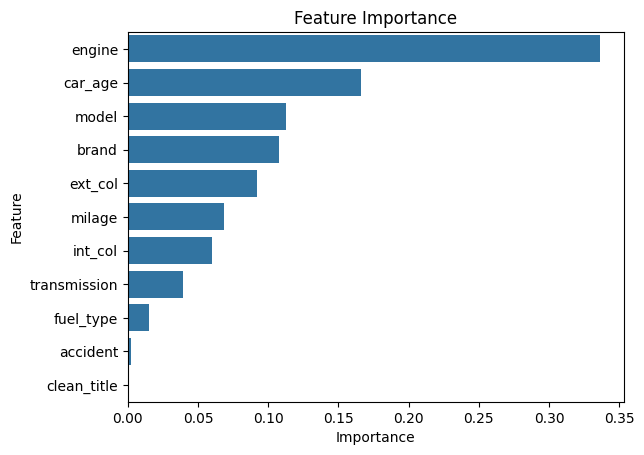

In [19]:
# 📌 11. Visualization
plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance")
plt.show()